# Finite-Energy GKP Approximation

In the paper $\textit{"Coherent manipulation of graph states composed of finite-energy GKP encoded qubits"}$, the finite-energy approximation of the GKP state is defined in Eq.~(6) as

\begin{equation}
|\tilde{k}_{q}\rangle
\propto
\sum_{n=-\infty}^{\infty}
e^{-\frac{\sigma^{2}x_{n}^{2}}{2}}
\hat{X}(x_{n})
|0_{r}\rangle,
\end{equation}

where

\begin{equation}
x_{n}=(2n+k_{q})\sqrt{\pi},
\qquad
k_{q}\in\{0,1\},
\end{equation}

and $|0_{r}\rangle$ denotes the squeezed vacuum state. The squeezed vacuum is obtained by applying the squeezing operator

\begin{equation}
\hat{S}(r)
=
\exp\left[
\frac{r}{2}
\left(
\hat{a}^{\dagger 2}
-
\hat{a}^{2}
\right)
\right]
\end{equation}

to the vacuum state,

\begin{equation}
|0_{r}\rangle
=
\hat{S}(r)|0\rangle.
\end{equation}

Projecting the squeezed vacuum onto the position basis gives the position-space wavefunction

\begin{equation}
\psi_{r}(q)
=
\langle q|0_{r}\rangle
=
\frac{1}{(\pi\sigma^{2})^{1/4}}
\exp\left(
-\frac{q^{2}}{2\sigma^{2}}
\right),
\end{equation}

where the squeezing parameter has been written as $\sigma=e^{-r}$. Applying the completeness relation

\begin{equation}
\hat{I}
=
\int_{-\infty}^{\infty}
dq\,
|q\rangle\langle q|
\end{equation}

allows the squeezed vacuum state to be reconstructed in the position basis,

\begin{equation}
|0_{r}\rangle
=
\frac{1}{(\pi\sigma^{2})^{1/4}}
\int_{-\infty}^{\infty}
dq\,
\exp\left(
-\frac{q^{2}}{2\sigma^{2}}
\right)
|q\rangle.
\end{equation}

Finally, applying the position displacement operator $\hat{X}(x_{n})$ translates the Gaussian wavepacket to the lattice position $x_{n}$,

\begin{equation}
\hat{X}(x_{n})
|0_{r}\rangle
=
\frac{1}{(\pi\sigma^{2})^{1/4}}
\int_{-\infty}^{\infty}
dq\,
\exp\left(
-\frac{q^{2}}{2\sigma^{2}}
\right)
|q+x_{n}\rangle.
\end{equation}

Making the change of variables $u=q+x_{n}$ gives

\begin{equation}
\hat{X}(x_{n})
|0_{r}\rangle
=
\frac{1}{(\pi\sigma^{2})^{1/4}}
\int_{-\infty}^{\infty}
du\,
\exp\left(
-\frac{(u-x_{n})^{2}}{2\sigma^{2}}
\right)
|u\rangle.
\end{equation}

Taking the position-space representation of this state yields

\begin{equation}
\langle q|
\hat{X}(x_{n})
|0_{r}\rangle
=
\frac{1}{(\pi\sigma^{2})^{1/4}}
\exp\left(
-\frac{(q-x_{n})^{2}}{2\sigma^{2}}
\right),
\end{equation}

which is precisely the finite-width Gaussian packet centred at the lattice site $x_{n}$. Consequently, the finite-energy GKP state is constructed as a coherent superposition of these displaced squeezed Gaussian wavepackets, weighted by the Gaussian envelope factor $e^{-\sigma^{2}x_{n}^{2}/2}$, written as

\begin{equation}
\psi_{GKP}(q) = \sum_{n=-\infty}^{\infty} e^{-\frac{\sigma^2((2n+k_{q})\sqrt{\pi})^2}{2}} \frac{1}{(\pi \sigma^2)^{1/4}} e^{-\frac{(q - (2n+k_{q})\sqrt{\pi})^{2}}{2\sigma^2}}
\end{equation}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Finite-energy GKP qubit: position wavefunctions and Wigner function

# $\sigma = 0.1$

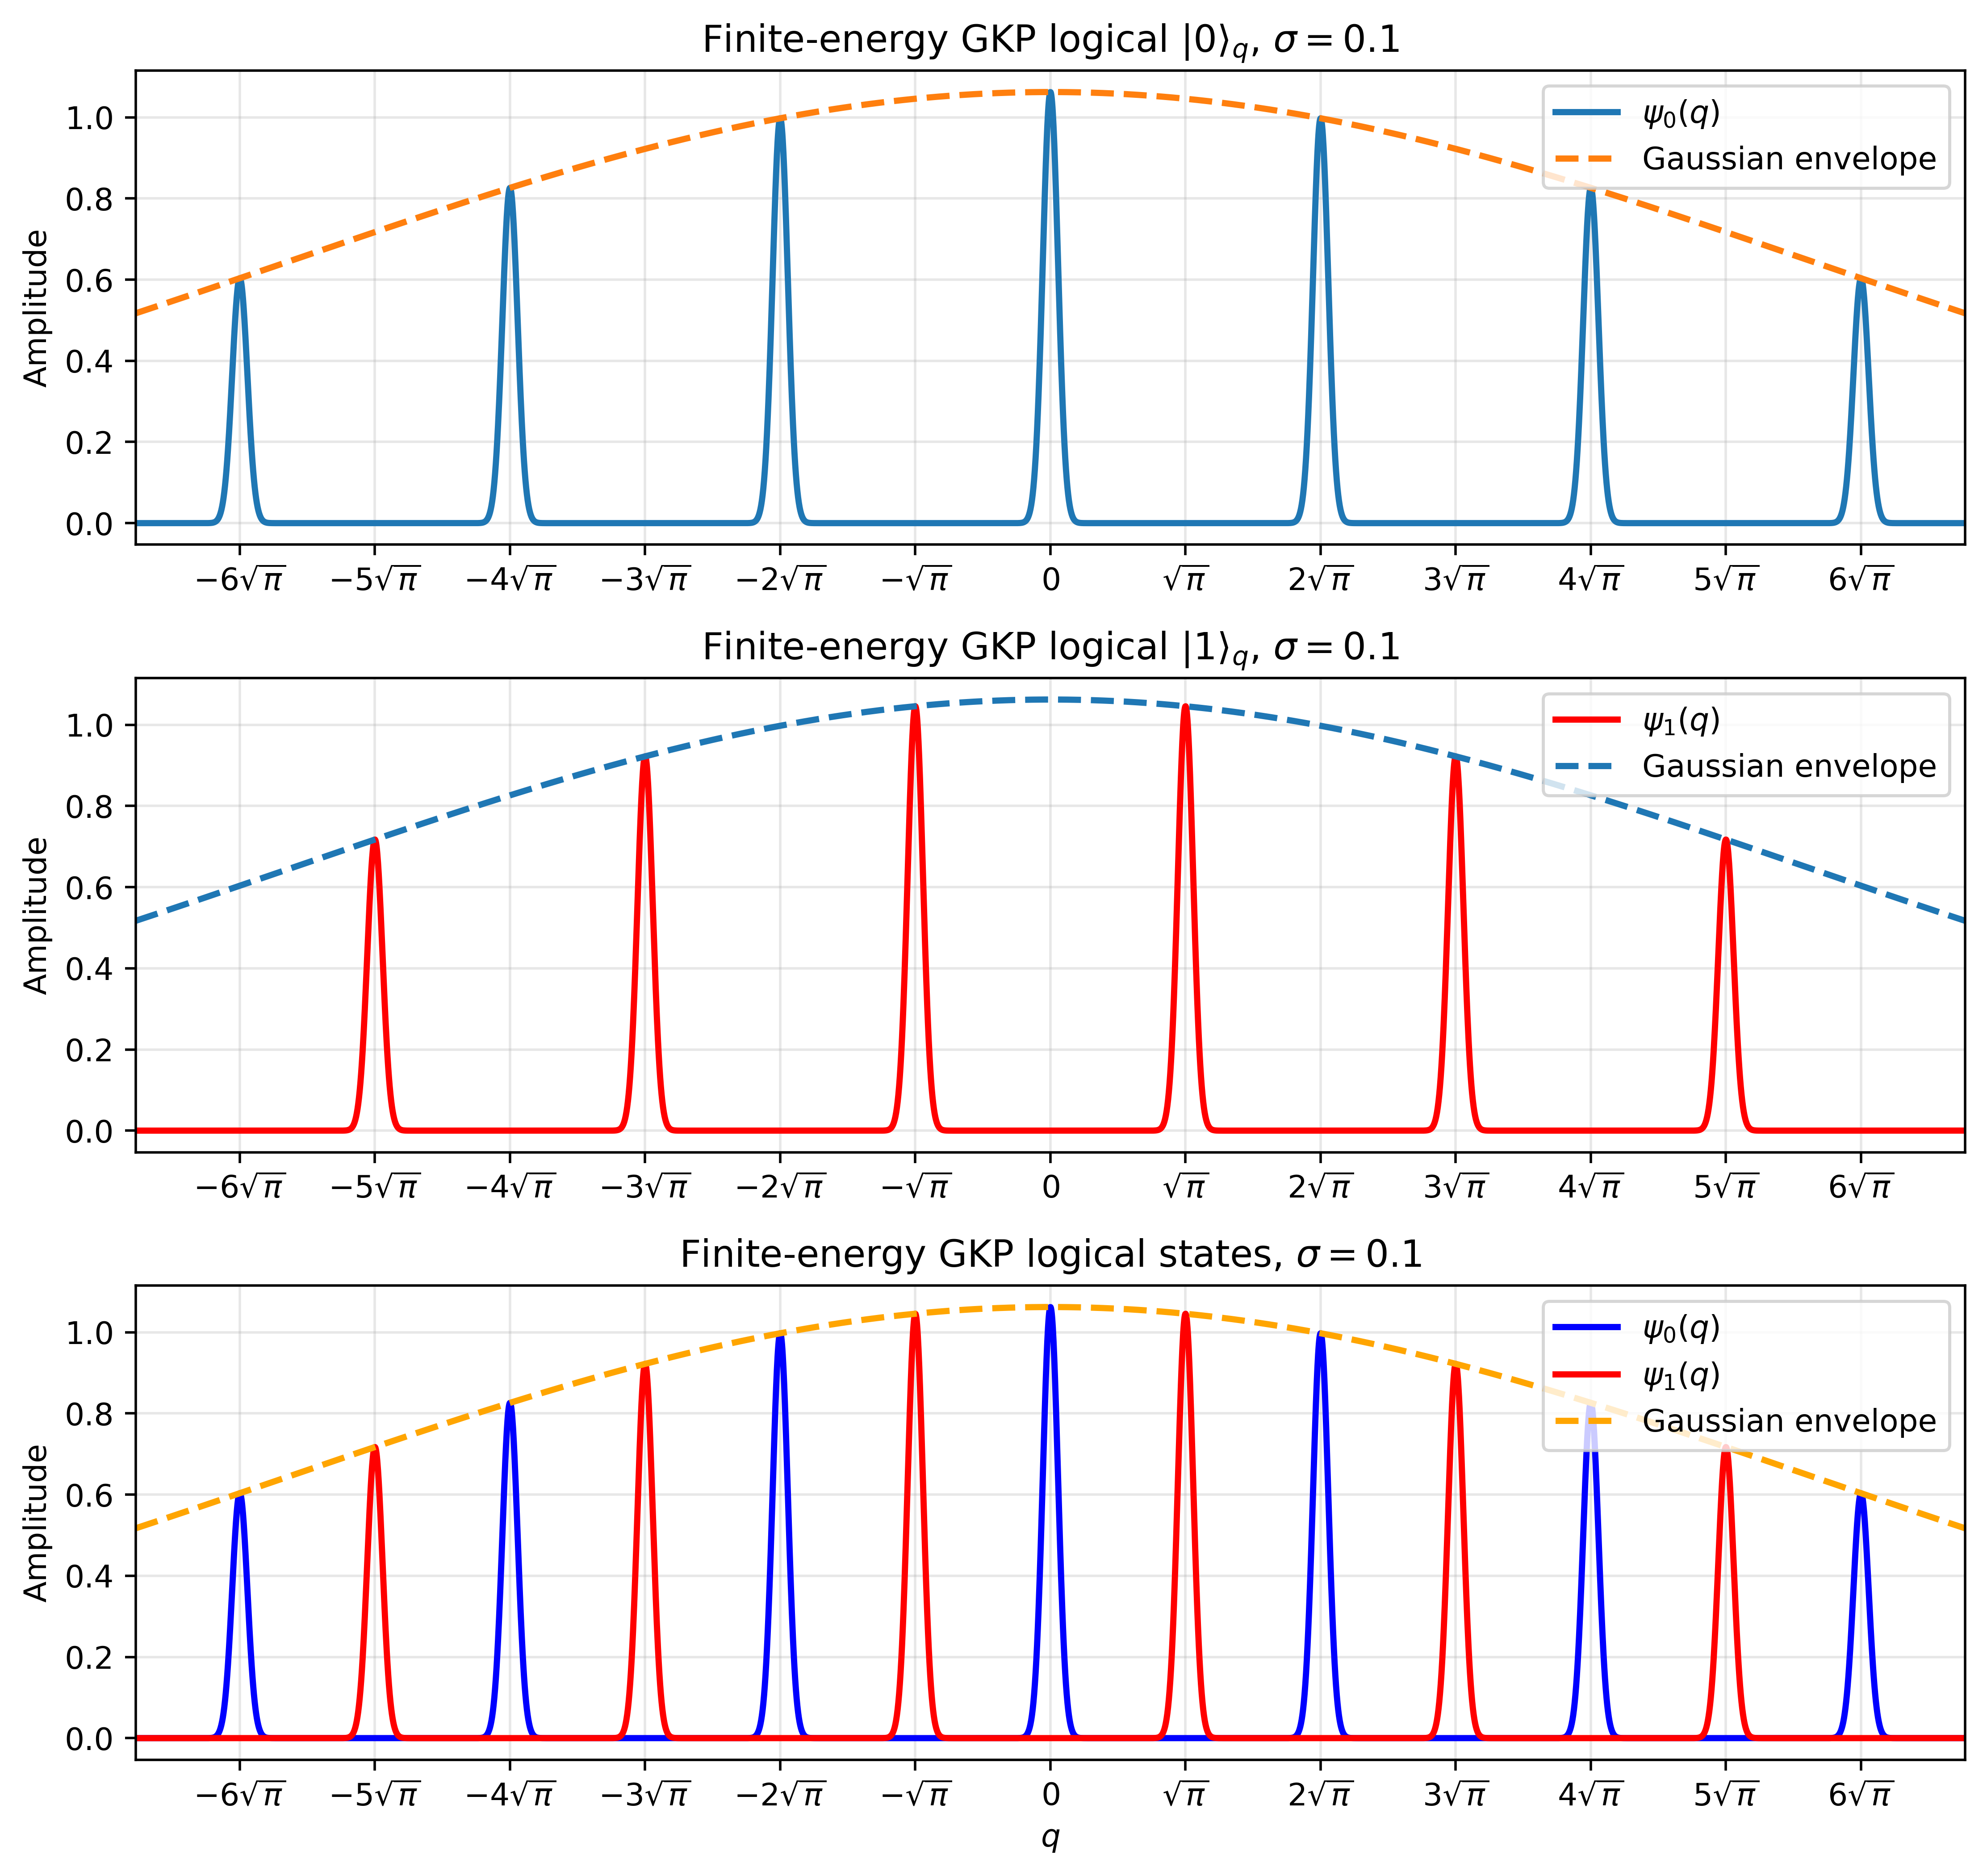

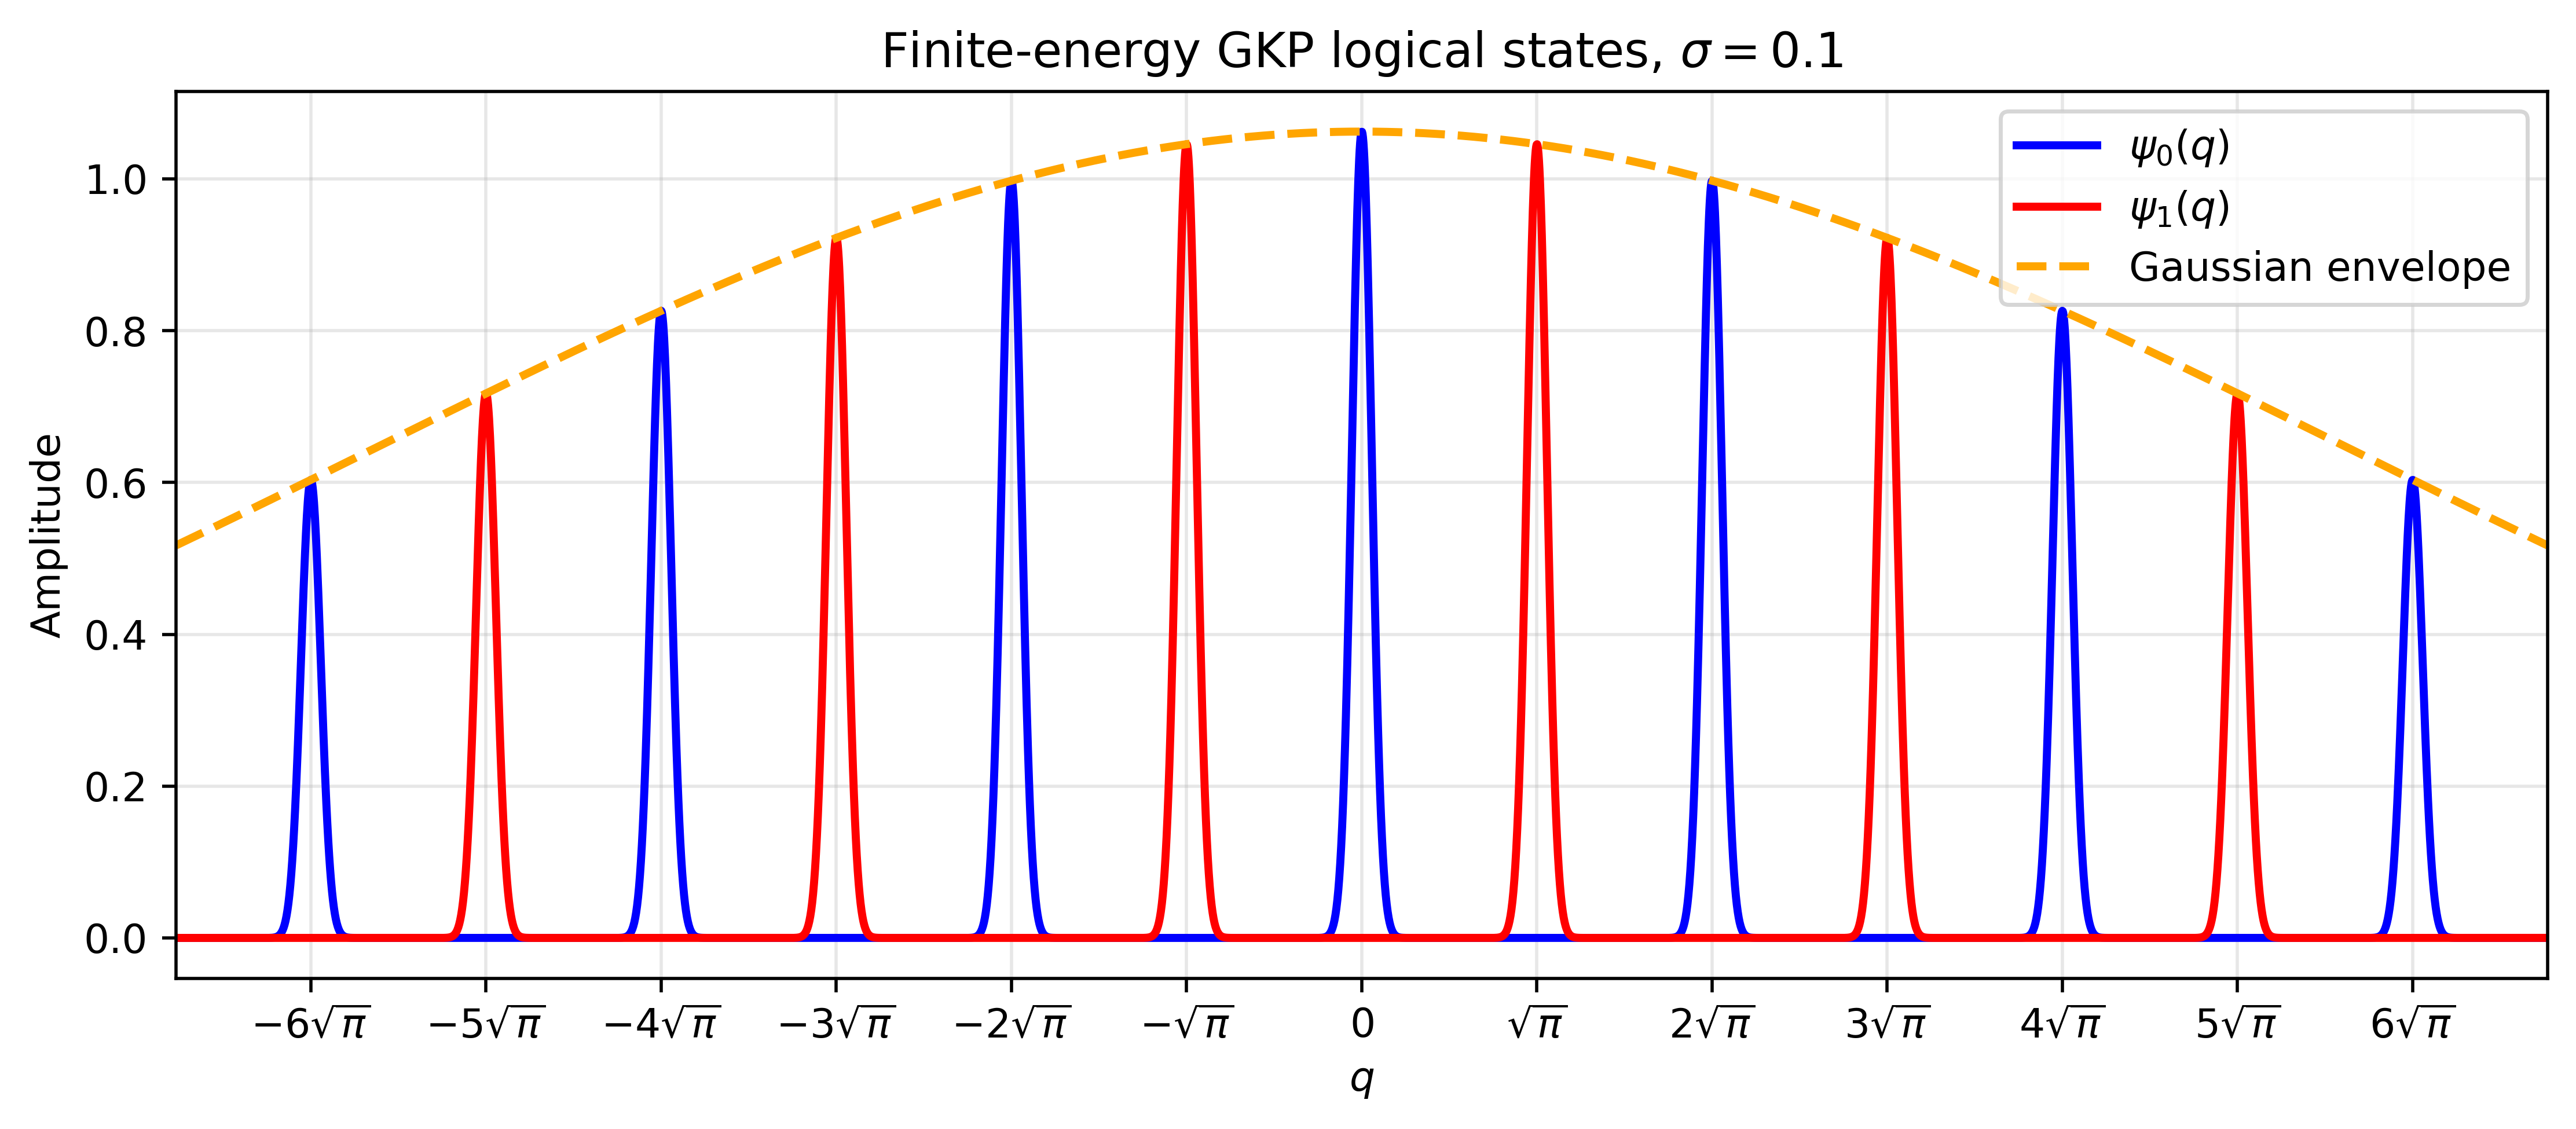

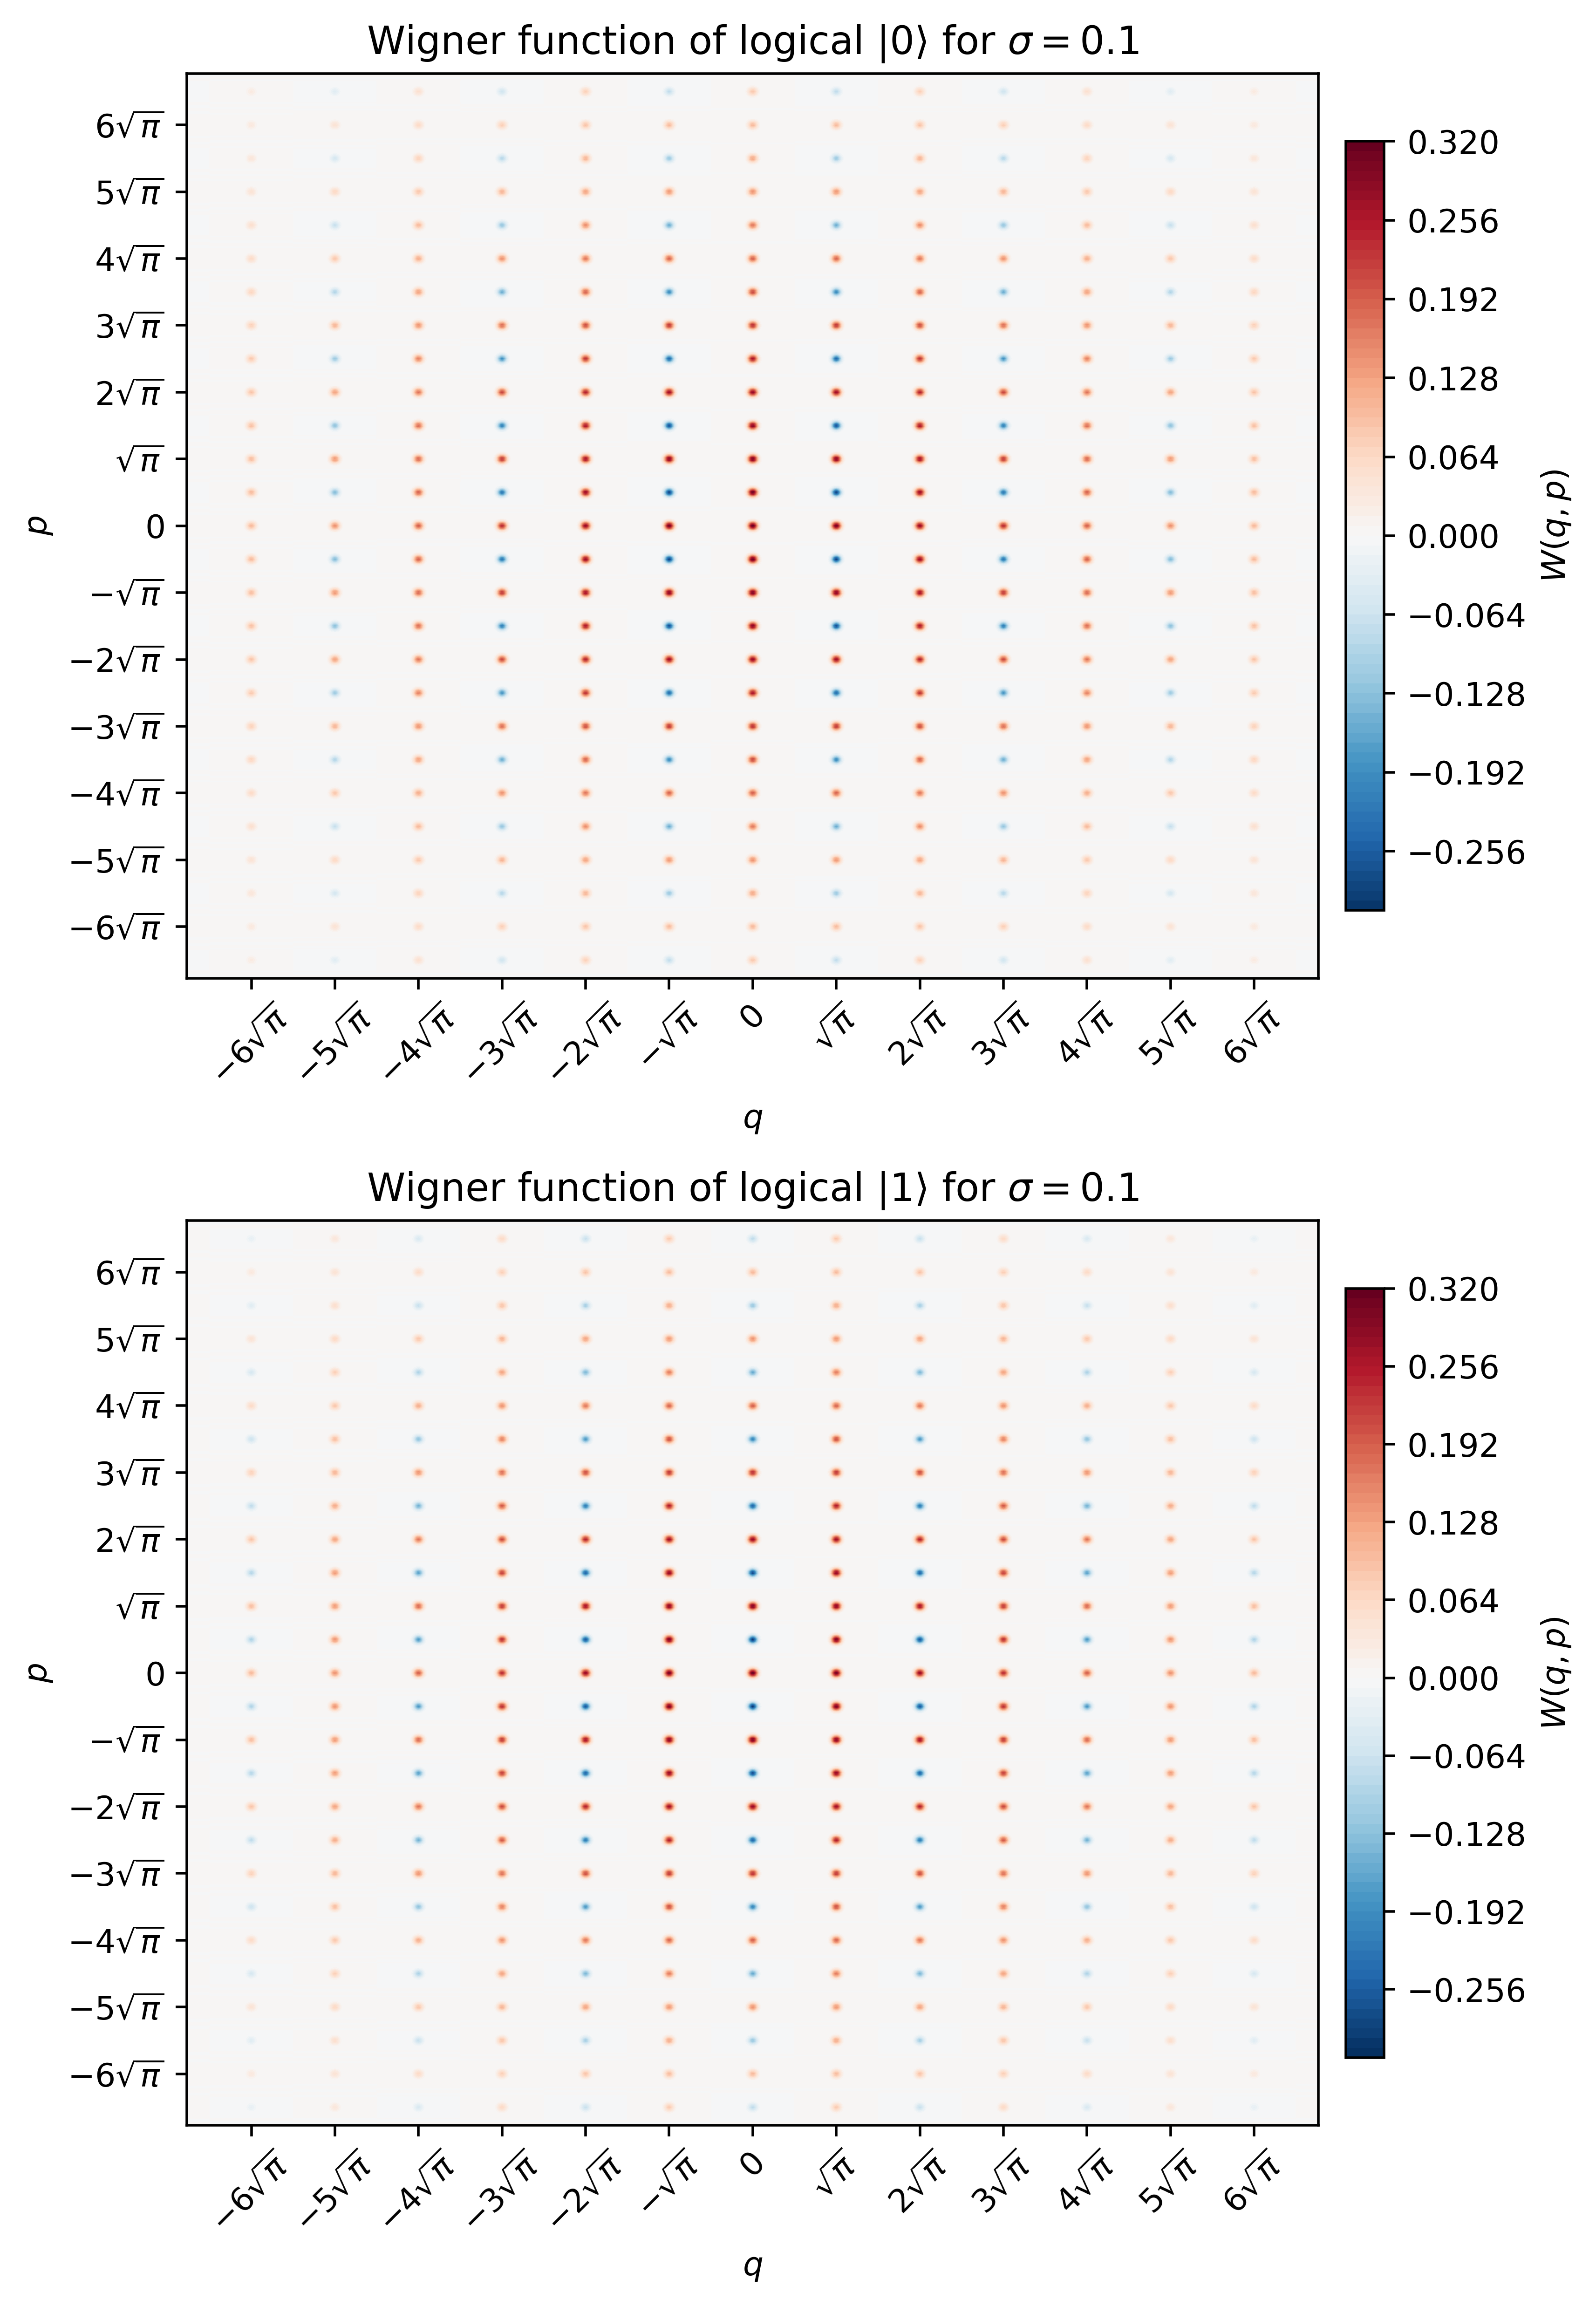

In [47]:
# ============================================================
# Single displaced squeezed Gaussian packet
# ============================================================

def finite_energy_gaussian_state(q, x0, sigma):
    """
    Position-space wavefunction of a displaced squeezed vacuum
    centred at x0.
    """
    return (
        (np.pi * sigma**2) ** (-0.25)
        * np.exp(-0.5 * ((q - x0) / sigma)**2)
    )


# ============================================================
# GKP lattice points
# ============================================================

def gkp_lattice_points(logical, n_cut):
    """
    GKP lattice positions

        x_n = (2n + logical) sqrt(pi)

    for logical = 0 or 1.
    """
    n = np.arange(-n_cut, n_cut + 1)
    return (2 * n + logical) * np.sqrt(np.pi)


# ============================================================
# Finite-energy envelope coefficients
# ============================================================

def finite_energy_gkp_envelope_weights(logical, sigma, n_cut):
    """
    Gaussian envelope coefficients for the finite-energy GKP state.

    The coefficients are normalised including the small overlap
    between neighbouring finite-width Gaussian packets.
    """

    x_n = gkp_lattice_points(logical, n_cut)

    # Gaussian envelope weighting
    weights = np.exp(-0.5 * (sigma * x_n)**2)

    # Overlap matrix of displaced Gaussian packets
    overlap = np.exp(
        -((x_n[:, None] - x_n[None, :])**2)
        / (4.0 * sigma**2)
    )

    # Normalisation of the full superposition
    norm = np.sum(
        weights[:, None]
        * np.conjugate(weights[None, :])
        * overlap
    )

    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("GKP state normalisation failed.")

    weights = weights / np.sqrt(norm)

    return x_n, weights


# ============================================================
# Finite-energy GKP position-space wavefunction
# ============================================================

def gkp_wavefunction(q, logical, sigma, n_cut):
    """
    Complete finite-energy GKP position-space wavefunction.
    """

    x_n, weights = finite_energy_gkp_envelope_weights(
        logical,
        sigma,
        n_cut
    )

    psi = np.zeros_like(q, dtype=complex)

    for x0, weight in zip(x_n, weights):
        psi += (
            weight
            * finite_energy_gaussian_state(q, x0, sigma)
        )

    return psi


# ============================================================
# Wigner function
# ============================================================

def gkp_wigner(q, p, logical, sigma, n_cut):
    """
    Wigner function of the finite-energy GKP superposition.
    """

    x_n, weights = finite_energy_gkp_envelope_weights(
        logical,
        sigma,
        n_cut
    )

    Q, P = np.meshgrid(q, p, indexing="xy")

    W = np.zeros_like(Q, dtype=complex)

    common_p = np.exp(-(sigma**2) * P**2)

    for xn, weight_n in zip(x_n, weights):

        for xm, weight_m in zip(x_n, weights):

            center = 0.5 * (xn + xm)

            term_q = np.exp(
                -((Q - center)**2) / sigma**2
            )

            term_phase = np.exp(
                -1j * P * (xm - xn)
            )

            W += (
                weight_n
                * np.conjugate(weight_m)
                * term_q
                * common_p
                * term_phase
            )

    return np.real(W) / np.pi


# ============================================================
# Parameters for visualisation
# ============================================================

# Use a visually resolvable sigma for the figure.
# This is an illustrative plot, not the numerical simulation value.
sigma = 0.1

n_cut = 8

# Dense q-grid so the finite-width Gaussian peaks are resolved
qmin, qmax = -12.0, 12.0
q = np.linspace(qmin, qmax, 5000)

# Phase-space grid for Wigner plots
pmin, pmax = -12.0, 12.0
p = np.linspace(pmin, pmax, 401)


# ============================================================
# Construct logical 0 and logical 1 wavefunctions
# ============================================================

psi_0 = gkp_wavefunction(
    q,
    logical=0,
    sigma=sigma,
    n_cut=n_cut
)

psi_1 = gkp_wavefunction(
    q,
    logical=1,
    sigma=sigma,
    n_cut=n_cut
)


# ============================================================
# Continuous Gaussian envelope for visualisation
# ============================================================

envelope = np.exp(
    -0.5 * (sigma * q)**2
)

# Normalise only for plotting, so that the envelope and
# wavefunction can be compared visually on the same axes.


# ============================================================
# Actual physically normalised wavefunctions
# ============================================================

psi_0_plot = np.real(psi_0)
psi_1_plot = np.real(psi_1)


# ============================================================
# Lattice positions and envelope coefficients
# ============================================================

x0, weights0 = finite_energy_gkp_envelope_weights(
    logical=0,
    sigma=sigma,
    n_cut=n_cut
)

x1, weights1 = finite_energy_gkp_envelope_weights(
    logical=1,
    sigma=sigma,
    n_cut=n_cut
)


# ============================================================
# Continuous coefficient envelopes on the physical
# wavefunction-amplitude scale
# ============================================================

gaussian_peak_amplitude = (
    np.pi * sigma**2
) ** (-0.25)

# Overall normalisation is already contained in weights0/weights1.
# Obtain the relative normalisation factors from the central
# coefficient envelope.

raw_weights0 = np.exp(-0.5 * (sigma * x0)**2)
raw_weights1 = np.exp(-0.5 * (sigma * x1)**2)

N0 = weights0[0] / raw_weights0[0]
N1 = weights1[0] / raw_weights1[0]

envelope_0 = (
    N0
    * gaussian_peak_amplitude
    * np.exp(-0.5 * (sigma * q)**2)
)

envelope_1 = (
    N1
    * gaussian_peak_amplitude
    * np.exp(-0.5 * (sigma * q)**2)
)

# psi_0_plot /= np.max(np.abs(psi_0_plot))
# psi_1_plot /= np.max(np.abs(psi_1_plot))
# envelope_plot = envelope / np.max(envelope)


# ============================================================
# Position-space wavefunctions
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 8.5),
    dpi=500,
    sharex=False
)


# ============================================================
# Define x-axis ticks in units of sqrt(pi)
# ============================================================

tick_integers = np.arange(-6, 7, 1)
tick_positions = tick_integers * np.sqrt(np.pi)

tick_labels = []

for j in tick_integers:

    if j == 0:
        label = r"$0$"

    elif j == 1:
        label = r"$\sqrt{\pi}$"

    elif j == -1:
        label = r"$-\sqrt{\pi}$"

    else:
        label = fr"${j}\sqrt{{\pi}}$"

    tick_labels.append(label)


# ============================================================
# Logical 0
# ============================================================

axes[0].plot(
    q,
    psi_0_plot,
    linewidth=2,
    label=r"$\psi_0(q)$"
)

axes[0].plot(
    q,
    envelope_0,
    "--",
    linewidth=2,
    label="Gaussian envelope"
)

axes[0].set_xlim(qmin, qmax)

axes[0].set_xticks(
    tick_positions,
    tick_labels
)

axes[0].set_ylabel(
    "Amplitude"
)

axes[0].set_title(
    fr"Finite-energy GKP logical $|0\rangle_q$, $\sigma={sigma}$"
)

axes[0].grid(
    True,
    alpha=0.3
)

axes[0].legend(loc="upper right")


# ============================================================
# Logical 1
# ============================================================

axes[1].plot(
    q,
    psi_1_plot,
    color="red",
    linewidth=2,
    label=r"$\psi_1(q)$"
)

axes[1].plot(
    q,
    envelope_1,
    "--",
    linewidth=2,
    label="Gaussian envelope"
)

axes[1].set_xlim(qmin, qmax)

axes[1].set_xticks(
    tick_positions,
    tick_labels
)

axes[1].set_ylabel(
    "Amplitude"
)

axes[1].set_title(
    fr"Finite-energy GKP logical $|1\rangle_q$, $\sigma={sigma}$"
)

axes[1].grid(
    True,
    alpha=0.3
)

axes[1].legend(loc="upper right")


# ============================================================
# Logical 0 and logical 1 together
# ============================================================

axes[2].plot(
    q,
    psi_0_plot,
    color="blue",
    linewidth=2,
    label=r"$\psi_0(q)$"
)

axes[2].plot(
    q,
    psi_1_plot,
    color="red",
    linewidth=2,
    label=r"$\psi_1(q)$"
)

# Use a single Gaussian envelope as a visual reference
axes[2].plot(
    q,
    envelope_0,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Gaussian envelope"
)

axes[2].set_xlim(qmin, qmax)

axes[2].set_xticks(
    tick_positions,
    tick_labels
)

axes[2].set_xlabel("$q$")

axes[2].set_ylabel(
    "Amplitude"
)

axes[2].set_title(
    fr"Finite-energy GKP logical states, $\sigma={sigma}$"
)

axes[2].grid(
    True,
    alpha=0.3
)

axes[2].legend(loc="upper right")


# ============================================================
# Final formatting
# ============================================================

plt.tight_layout()
plt.show()


# ============================================================
# Position-space wavefunctions
# ============================================================

fig, ax = plt.subplots(
    1,
    1,
    figsize=(9,4),
    dpi=500,
    sharex=False
)


# ============================================================
# Define x-axis ticks in units of sqrt(pi)
# ============================================================

tick_integers = np.arange(-6, 7, 1)
tick_positions = tick_integers * np.sqrt(np.pi)

tick_labels = []

for j in tick_integers:

    if j == 0:
        label = r"$0$"

    elif j == 1:
        label = r"$\sqrt{\pi}$"

    elif j == -1:
        label = r"$-\sqrt{\pi}$"

    else:
        label = fr"${j}\sqrt{{\pi}}$"

    tick_labels.append(label)


# ============================================================
# Logical 0 and logical 1 together
# ============================================================

ax.plot(
    q,
    psi_0_plot,
    color="blue",
    linewidth=2,
    label=r"$\psi_0(q)$"
)

ax.plot(
    q,
    psi_1_plot,
    color="red",
    linewidth=2,
    label=r"$\psi_1(q)$"
)

# Use a single Gaussian envelope as a visual reference
ax.plot(
    q,
    envelope_0,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Gaussian envelope"
)

ax.set_xlim(qmin, qmax)

ax.set_xticks(
    tick_positions,
    tick_labels
)

ax.set_xlabel("$q$")

ax.set_ylabel(
    "Amplitude"
)

ax.set_title(
    fr"Finite-energy GKP logical states, $\sigma={sigma}$"
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend(loc="upper right")


# ============================================================
# Final formatting
# ============================================================

plt.tight_layout()
plt.show()

# ============================================================
# Wigner functions
# ============================================================

W0 = gkp_wigner(
    q,
    p,
    logical=0,
    sigma=sigma,
    n_cut=n_cut
)

W1 = gkp_wigner(
    q,
    p,
    logical=1,
    sigma=sigma,
    n_cut=n_cut
)


# Use a common colour scale for direct comparison
vmin = min(
    np.min(W0),
    np.min(W1)
)

vmax = max(
    np.max(W0),
    np.max(W1)
)

norm = TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax
)


# ============================================================
# Wigner-function figure
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(7,10),
    dpi=500
)

# ------------------------------------------------------------
# Logical 0
# ------------------------------------------------------------

im0 = axes[0].contourf(
    q,
    p,
    W0,
    levels=100,
    cmap="RdBu_r",
    norm=norm
)

axes[0].set_title(
    fr"Wigner function of logical $|0\rangle$ for $\sigma={sigma}$"
)

axes[0].set_xlabel("$q$")
axes[0].set_ylabel("$p$")

fig.colorbar(
    im0,
    ax=axes[0],
    shrink=0.85,
    pad=0.02,
    label=r"$W(q,p)$"
)


# ------------------------------------------------------------
# Logical 1
# ------------------------------------------------------------

im1 = axes[1].contourf(
    q,
    p,
    W1,
    levels=100,
    cmap="RdBu_r",
    norm=norm
)

axes[1].set_title(
    fr"Wigner function of logical $|1\rangle$ for $\sigma={sigma}$"
)

axes[1].set_xlabel("$q$")
axes[1].set_ylabel("$p$")

fig.colorbar(
    im1,
    ax=axes[1],
    shrink=0.85,
    pad=0.02,
    label=r"$W(q,p)$"
)

for ax in axes:

    # q-axis
    ax.set_xticks(
        tick_positions,
        tick_labels
    )

    # p-axis
    ax.set_yticks(
        tick_positions,
        tick_labels
    )

    # Rotate q labels slightly for readability
    ax.tick_params(
        axis="x",
        labelrotation=45
    )

    # Keep p labels horizontal
    ax.tick_params(
        axis="y",
        labelrotation=0
    )


plt.tight_layout()
plt.show()

# $\sigma = 0.3$

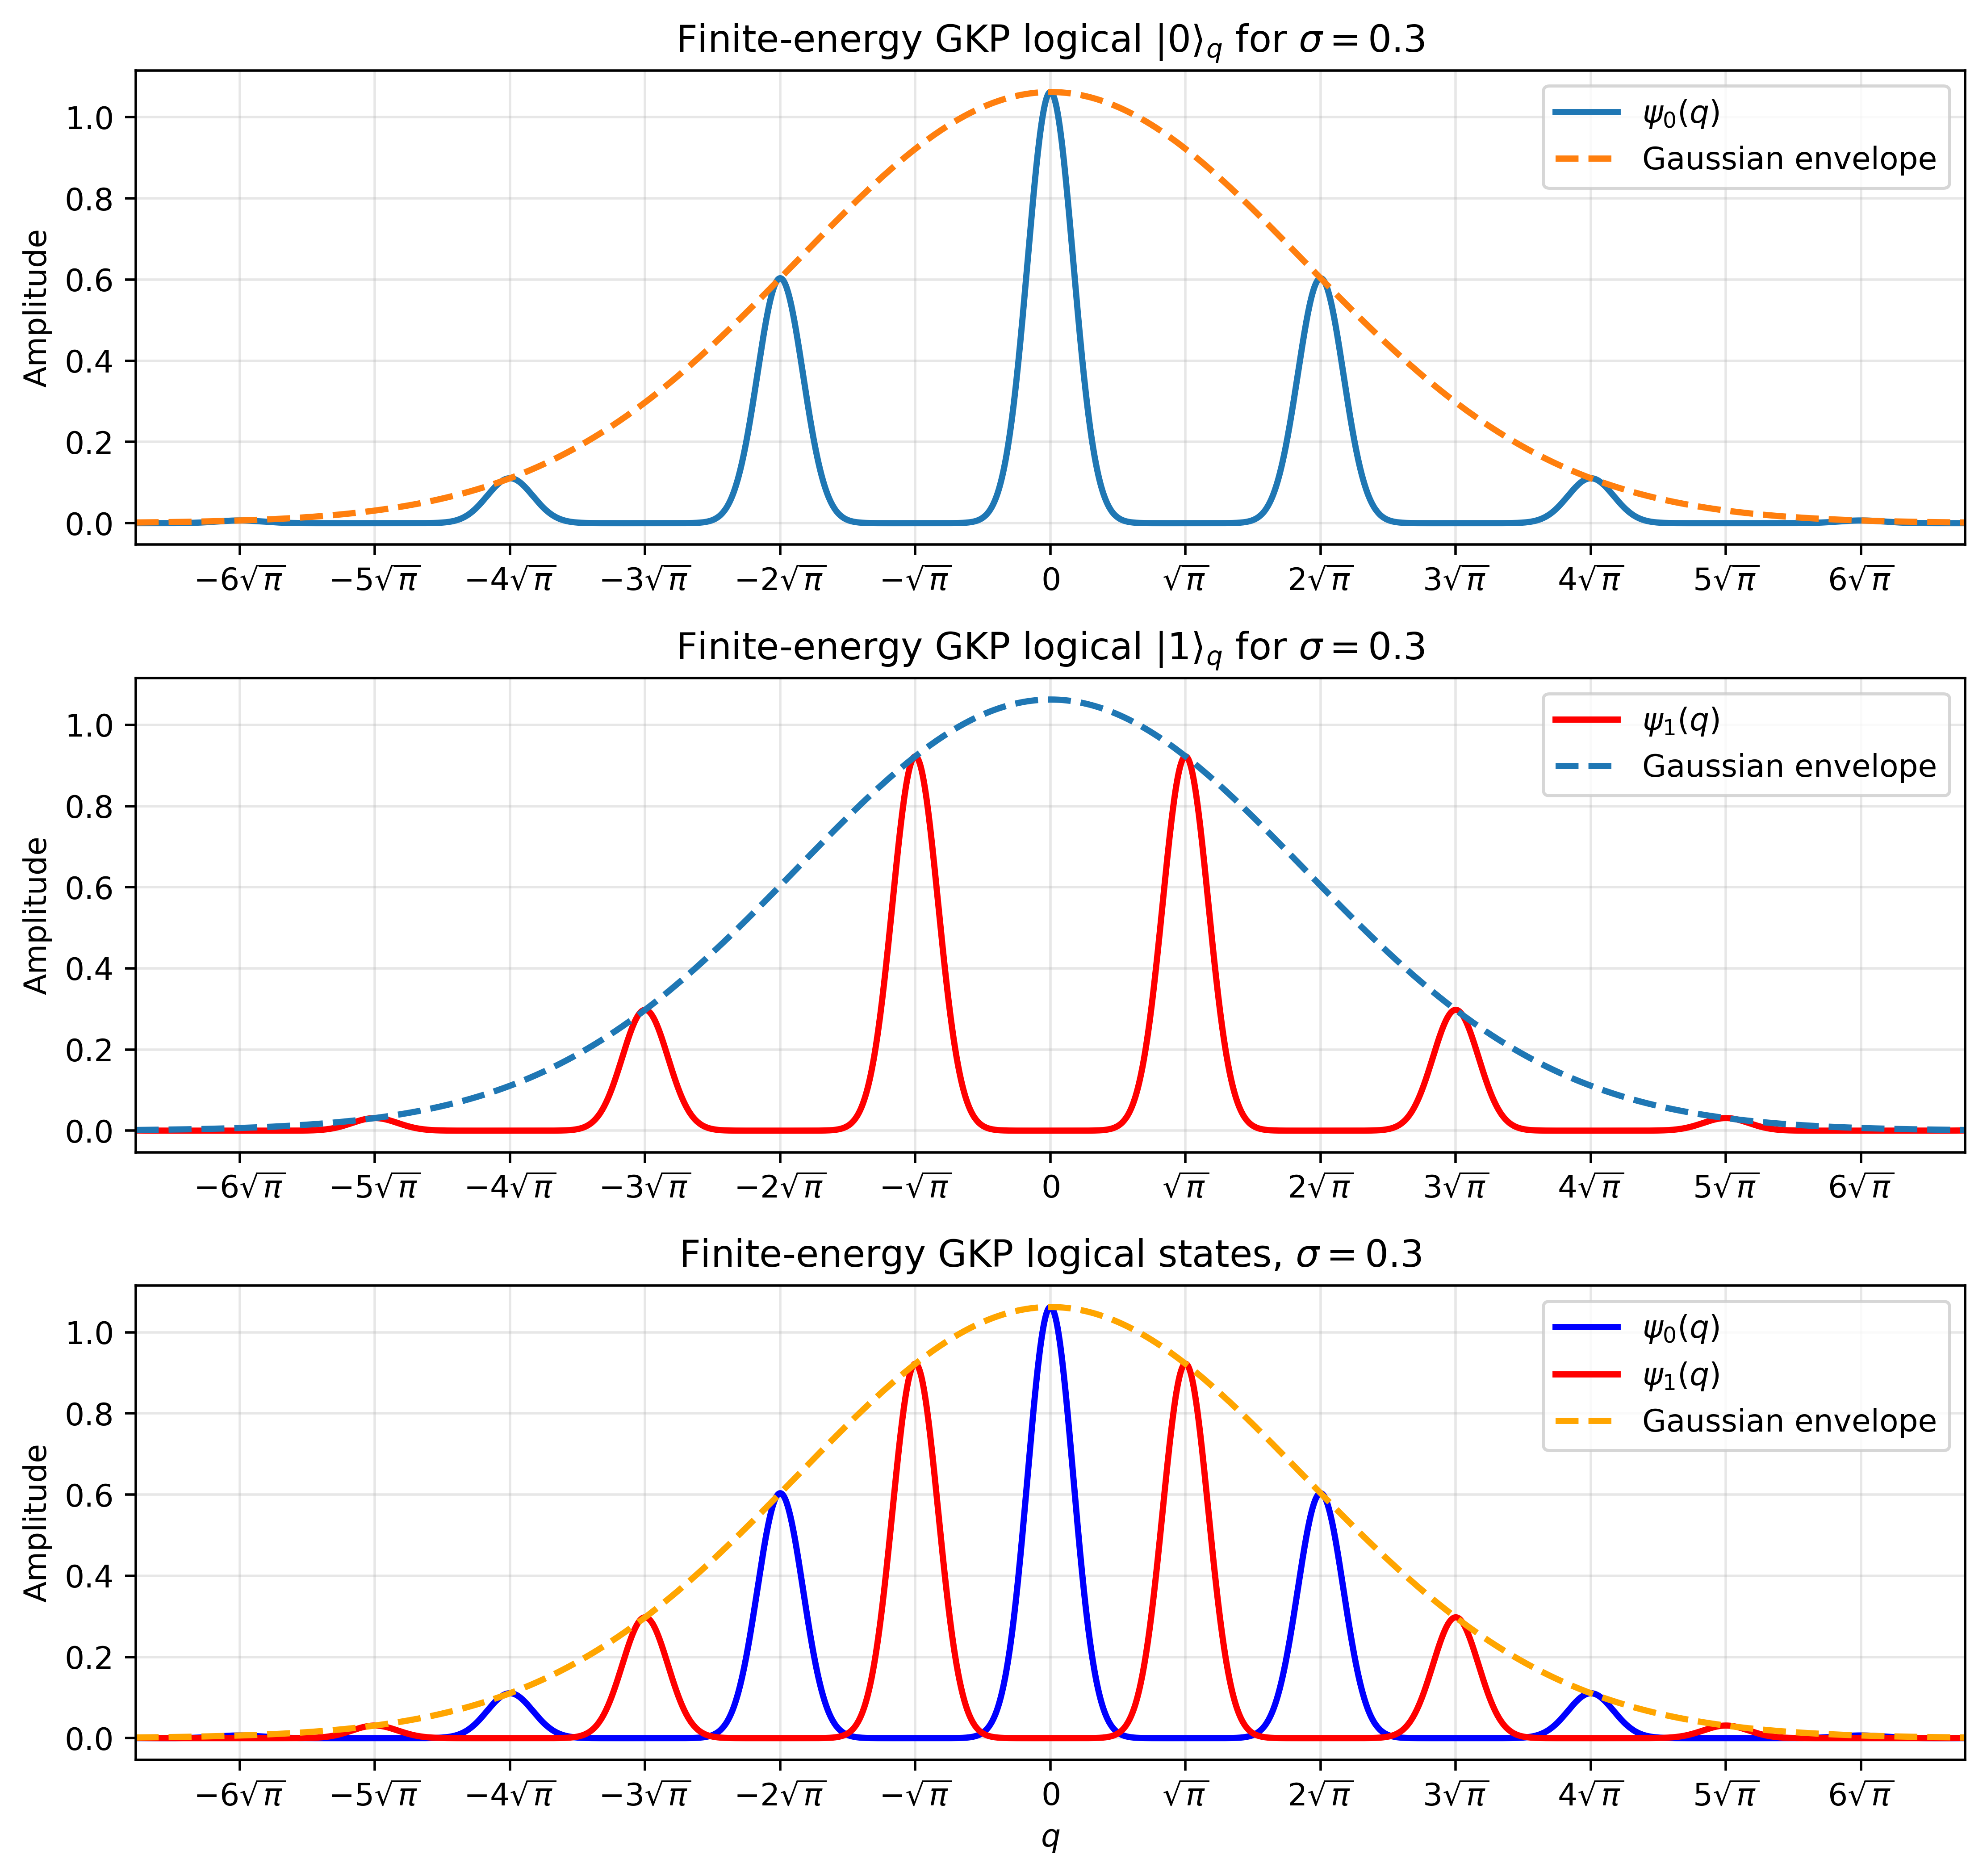

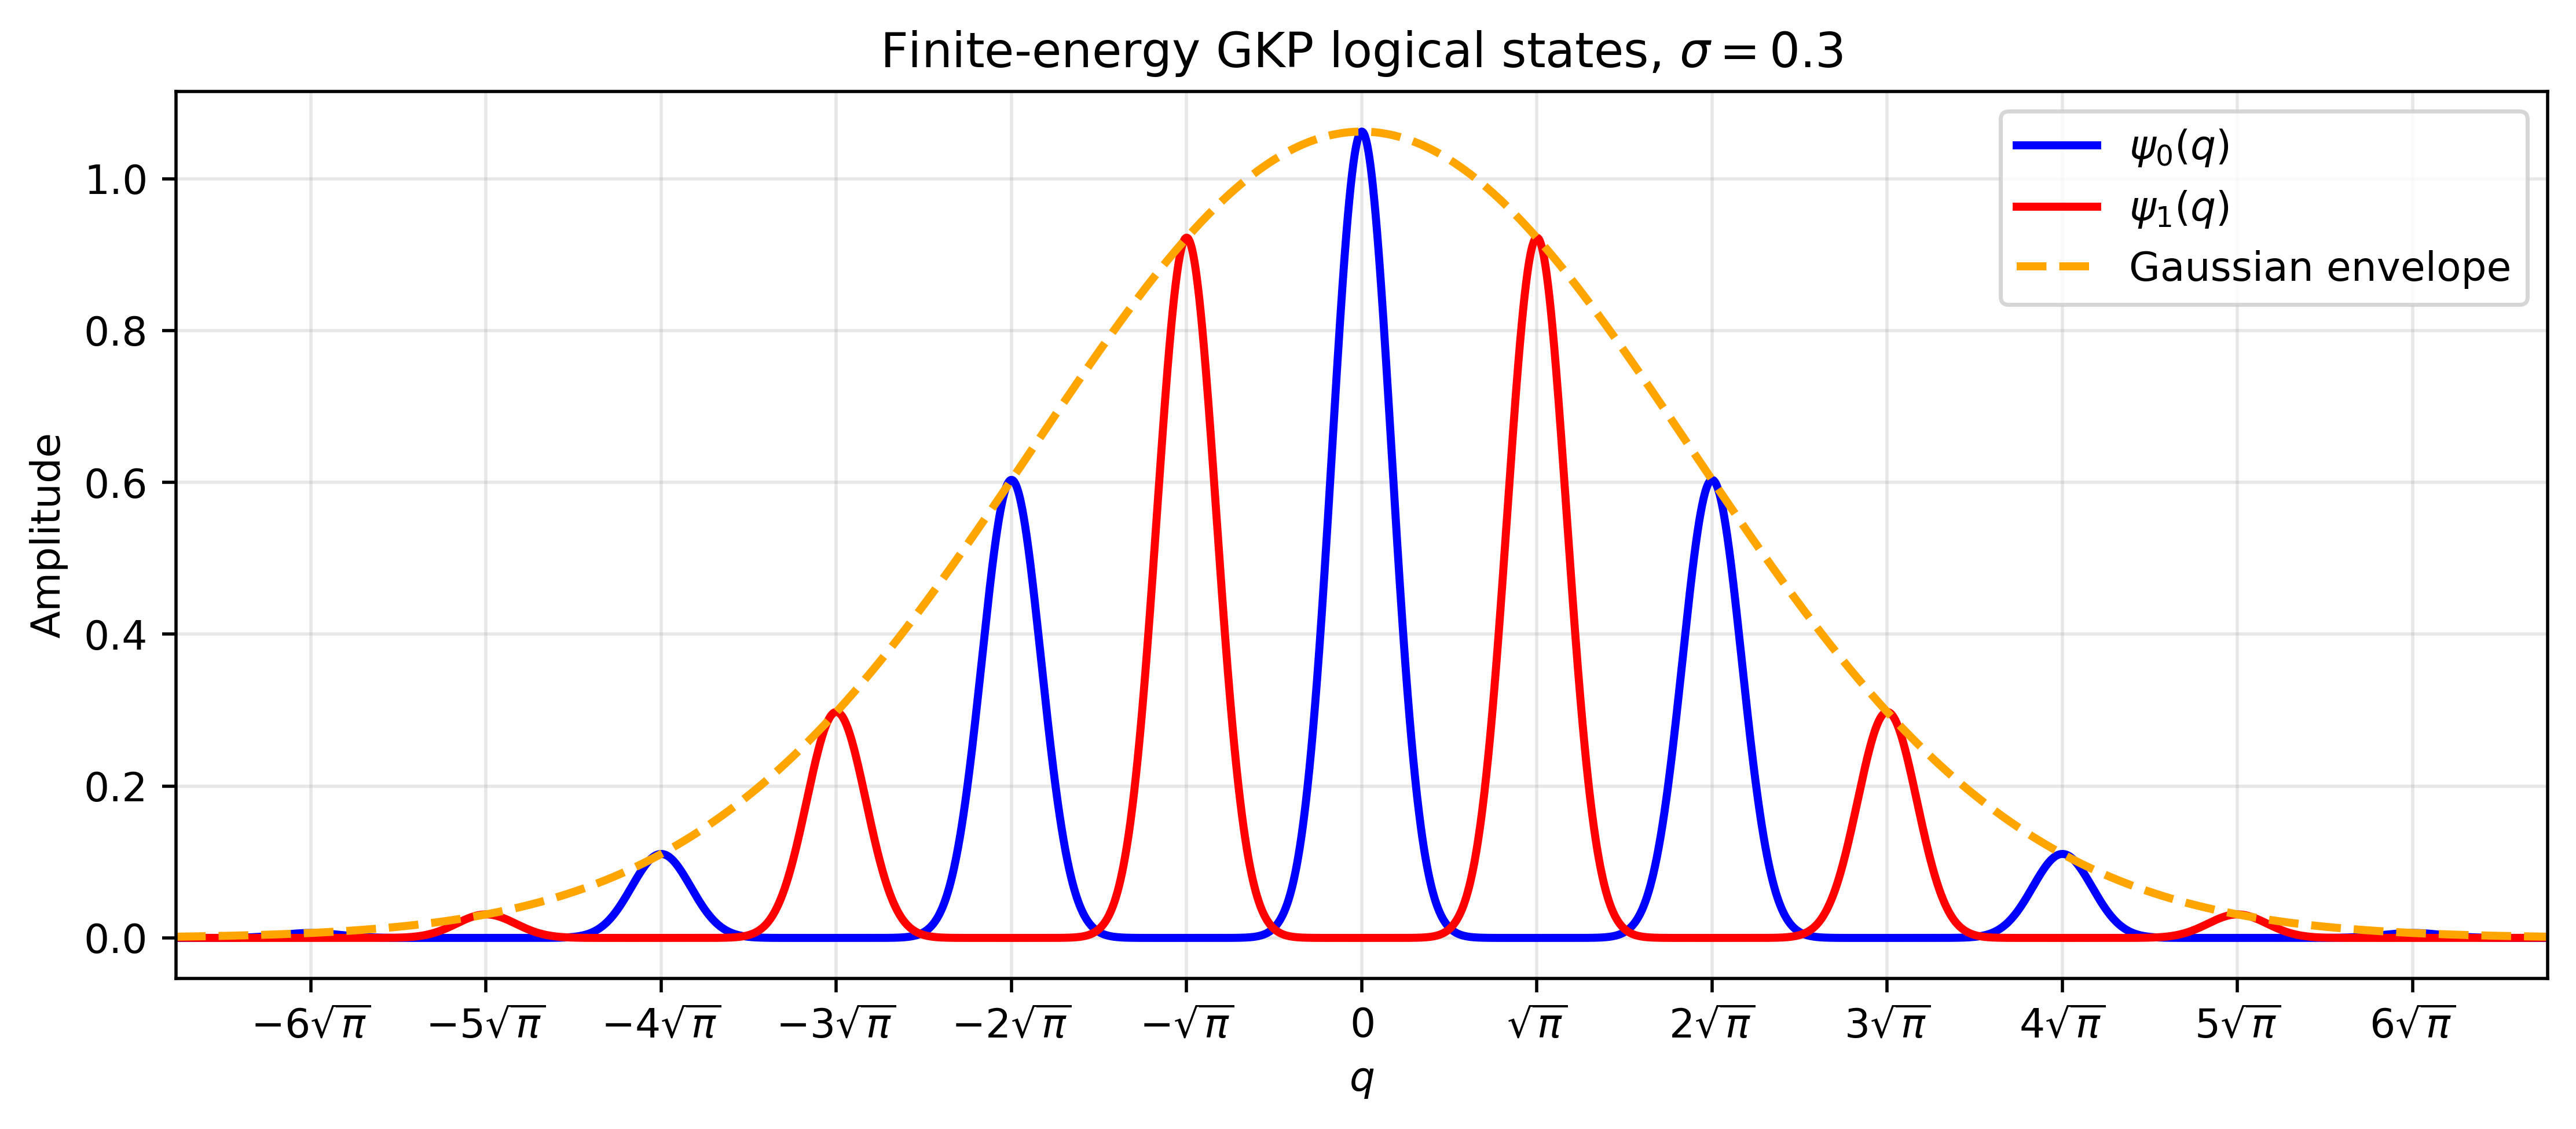

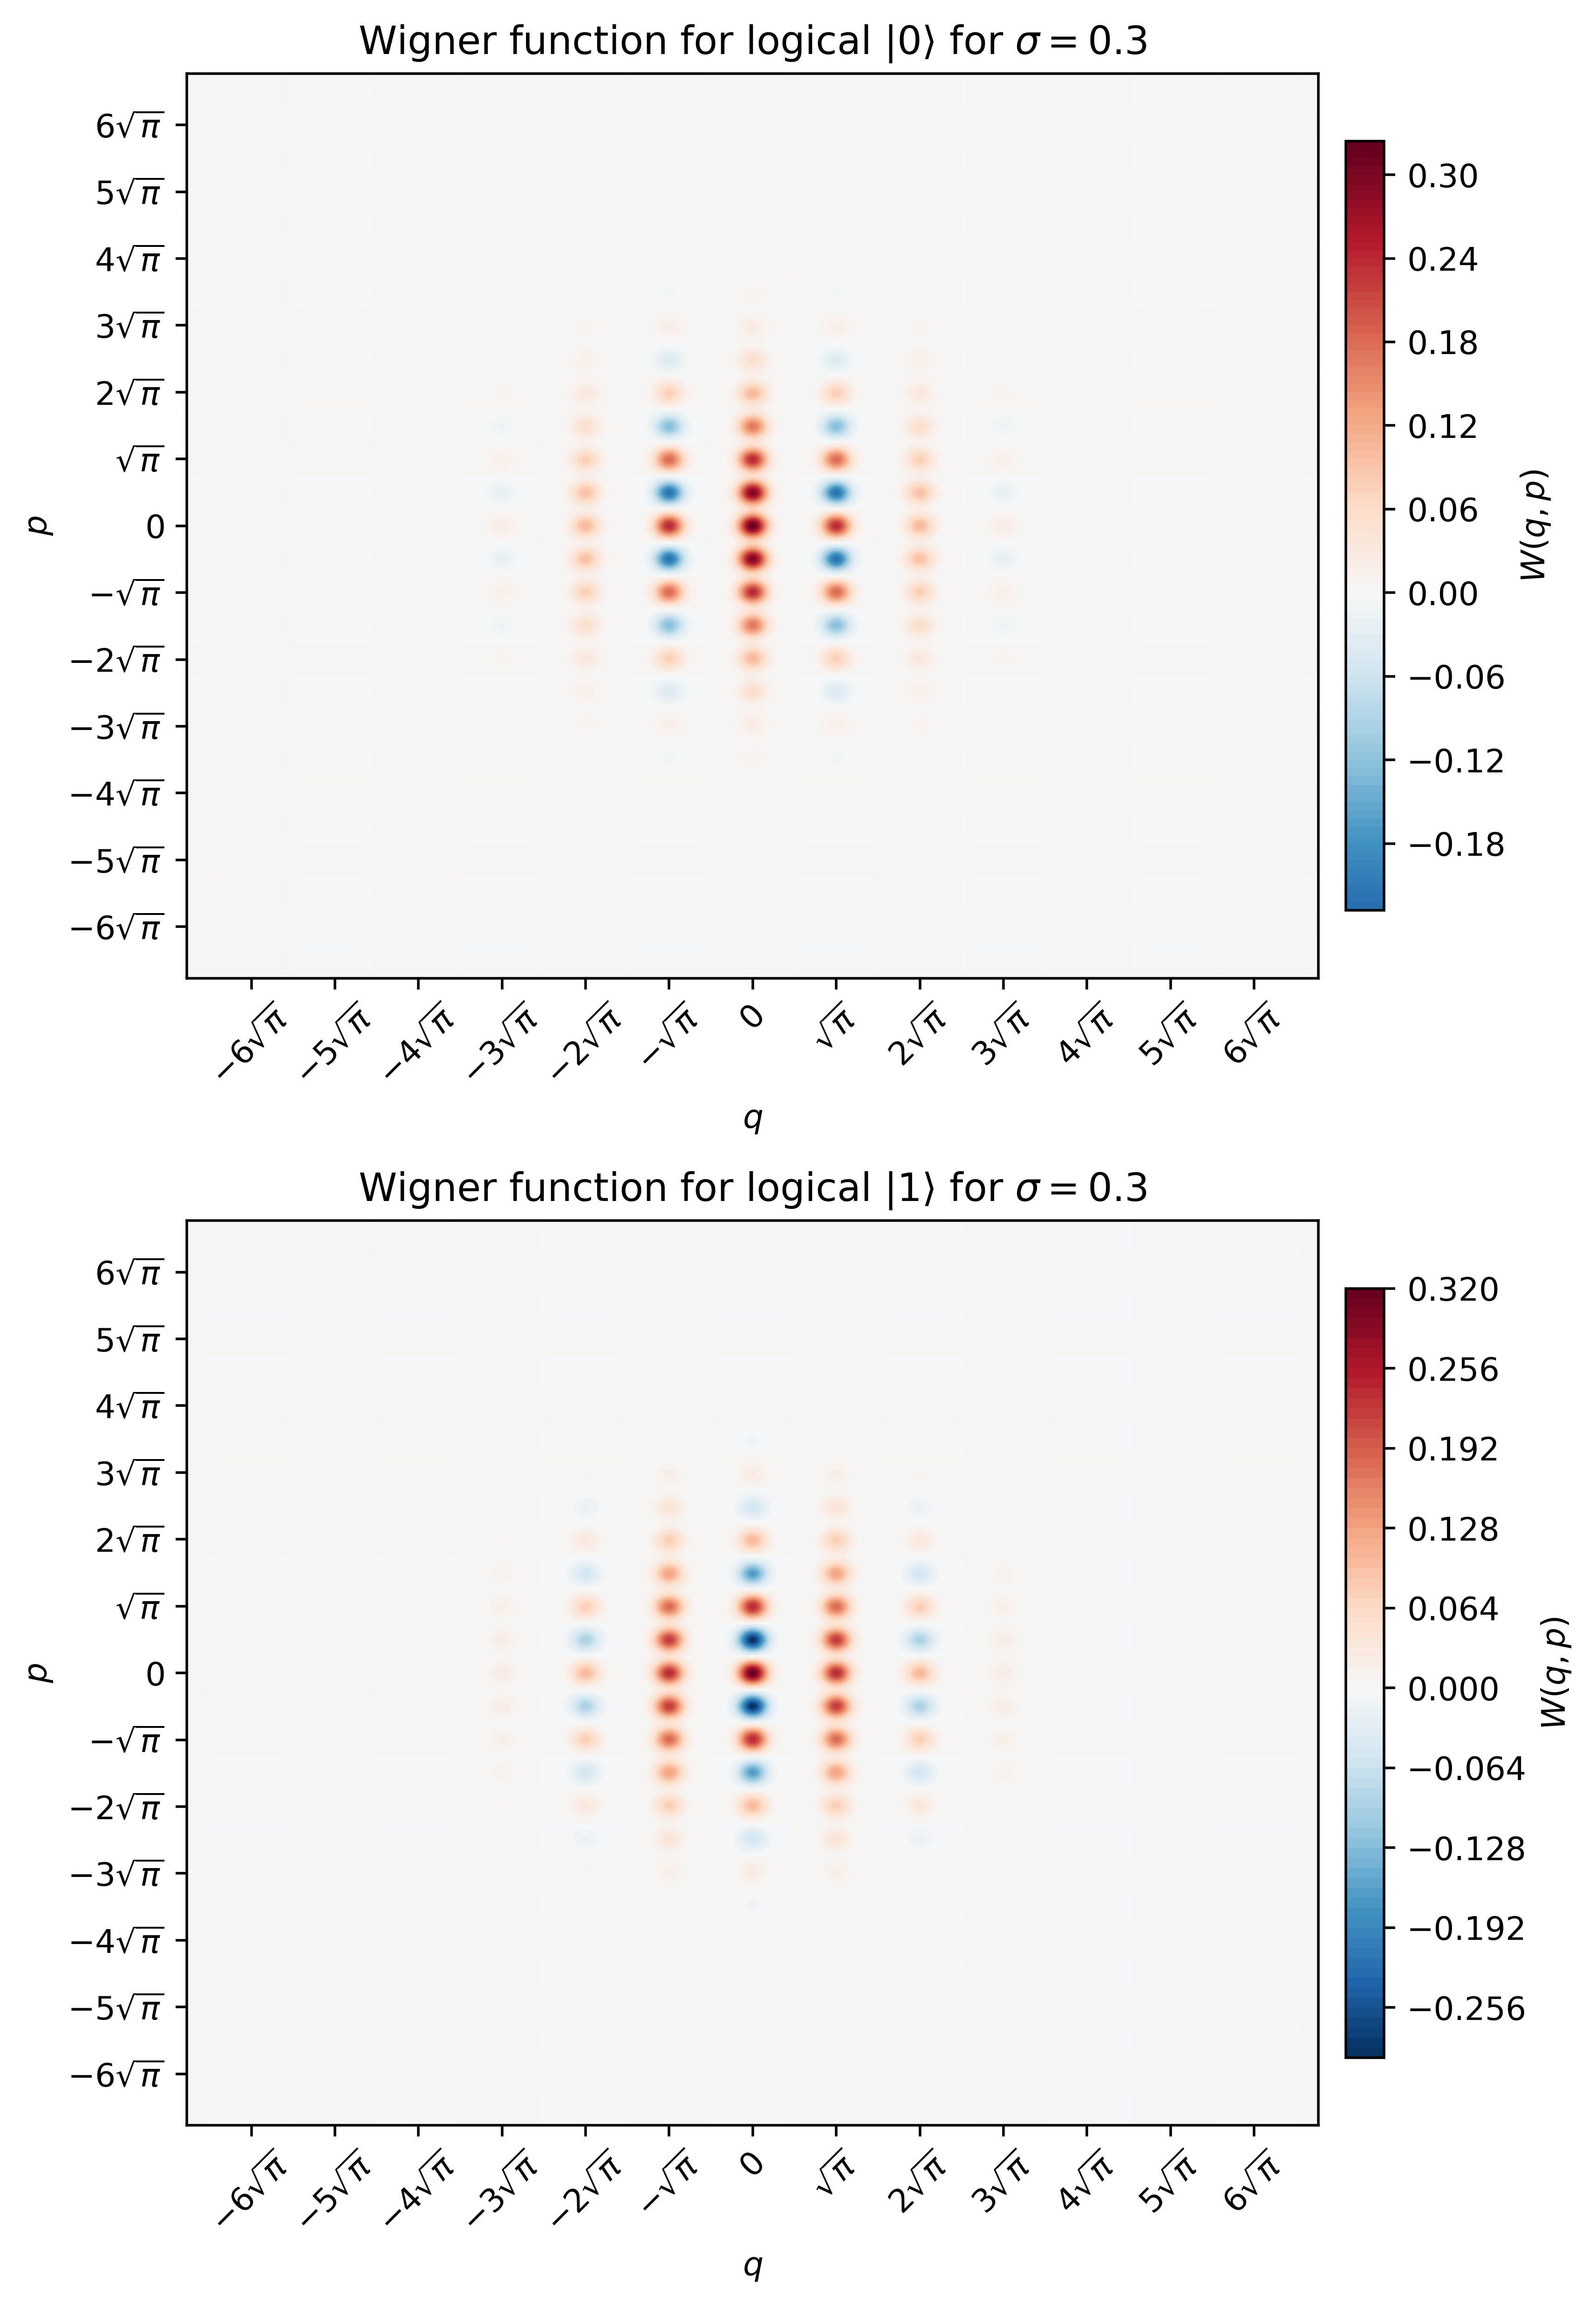

In [46]:
# ============================================================
# Single displaced squeezed Gaussian packet
# ============================================================

def finite_energy_gaussian_state(q, x0, sigma):
    """
    Position-space wavefunction of a displaced squeezed vacuum
    centred at x0.
    """
    return (
        (np.pi * sigma**2) ** (-0.25)
        * np.exp(-0.5 * ((q - x0) / sigma)**2)
    )


# ============================================================
# GKP lattice points
# ============================================================

def gkp_lattice_points(logical, n_cut):
    """
    GKP lattice positions

        x_n = (2n + logical) sqrt(pi)

    for logical = 0 or 1.
    """
    n = np.arange(-n_cut, n_cut + 1)
    return (2 * n + logical) * np.sqrt(np.pi)


# ============================================================
# Finite-energy envelope coefficients
# ============================================================

def finite_energy_gkp_envelope_weights(logical, sigma, n_cut):
    """
    Gaussian envelope coefficients for the finite-energy GKP state.

    The coefficients are normalised including the small overlap
    between neighbouring finite-width Gaussian packets.
    """

    x_n = gkp_lattice_points(logical, n_cut)

    # Gaussian envelope weighting
    weights = np.exp(-0.5 * (sigma * x_n)**2)

    # Overlap matrix of displaced Gaussian packets
    overlap = np.exp(
        -((x_n[:, None] - x_n[None, :])**2)
        / (4.0 * sigma**2)
    )

    # Normalisation of the full superposition
    norm = np.sum(
        weights[:, None]
        * np.conjugate(weights[None, :])
        * overlap
    )

    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("GKP state normalisation failed.")

    weights = weights / np.sqrt(norm)

    return x_n, weights


# ============================================================
# Finite-energy GKP position-space wavefunction
# ============================================================

def gkp_wavefunction(q, logical, sigma, n_cut):
    """
    Complete finite-energy GKP position-space wavefunction.
    """

    x_n, weights = finite_energy_gkp_envelope_weights(
        logical,
        sigma,
        n_cut
    )

    psi = np.zeros_like(q, dtype=complex)

    for x0, weight in zip(x_n, weights):
        psi += (
            weight
            * finite_energy_gaussian_state(q, x0, sigma)
        )

    return psi


# ============================================================
# Wigner function
# ============================================================

def gkp_wigner(q, p, logical, sigma, n_cut):
    """
    Wigner function of the finite-energy GKP superposition.
    """

    x_n, weights = finite_energy_gkp_envelope_weights(
        logical,
        sigma,
        n_cut
    )

    Q, P = np.meshgrid(q, p, indexing="xy")

    W = np.zeros_like(Q, dtype=complex)

    common_p = np.exp(-(sigma**2) * P**2)

    for xn, weight_n in zip(x_n, weights):

        for xm, weight_m in zip(x_n, weights):

            center = 0.5 * (xn + xm)

            term_q = np.exp(
                -((Q - center)**2) / sigma**2
            )

            term_phase = np.exp(
                -1j * P * (xm - xn)
            )

            W += (
                weight_n
                * np.conjugate(weight_m)
                * term_q
                * common_p
                * term_phase
            )

    return np.real(W) / np.pi


# ============================================================
# Parameters for visualisation
# ============================================================

# Use a visually resolvable sigma for the figure.
# This is an illustrative plot, not the numerical simulation value.
sigma = 0.3

n_cut = 8

# Dense q-grid so the finite-width Gaussian peaks are resolved
qmin, qmax = -12.0, 12.0
q = np.linspace(qmin, qmax, 5000)

# Phase-space grid for Wigner plots
pmin, pmax = -12.0, 12.0
p = np.linspace(pmin, pmax, 401)


# ============================================================
# Construct logical 0 and logical 1 wavefunctions
# ============================================================

psi_0 = gkp_wavefunction(
    q,
    logical=0,
    sigma=sigma,
    n_cut=n_cut
)

psi_1 = gkp_wavefunction(
    q,
    logical=1,
    sigma=sigma,
    n_cut=n_cut
)


# ============================================================
# Continuous Gaussian envelope for visualisation
# ============================================================

envelope = np.exp(
    -0.5 * (sigma * q)**2
)

# Normalise only for plotting, so that the envelope and
# wavefunction can be compared visually on the same axes.


# ============================================================
# Actual physically normalised wavefunctions
# ============================================================

psi_0_plot = np.real(psi_0)
psi_1_plot = np.real(psi_1)


# ============================================================
# Lattice positions and envelope coefficients
# ============================================================

x0, weights0 = finite_energy_gkp_envelope_weights(
    logical=0,
    sigma=sigma,
    n_cut=n_cut
)

x1, weights1 = finite_energy_gkp_envelope_weights(
    logical=1,
    sigma=sigma,
    n_cut=n_cut
)


# ============================================================
# Continuous coefficient envelopes on the physical
# wavefunction-amplitude scale
# ============================================================

gaussian_peak_amplitude = (
    np.pi * sigma**2
) ** (-0.25)

# Overall normalisation is already contained in weights0/weights1.
# Obtain the relative normalisation factors from the central
# coefficient envelope.

raw_weights0 = np.exp(-0.5 * (sigma * x0)**2)
raw_weights1 = np.exp(-0.5 * (sigma * x1)**2)

N0 = weights0[0] / raw_weights0[0]
N1 = weights1[0] / raw_weights1[0]

envelope_0 = (
    N0
    * gaussian_peak_amplitude
    * np.exp(-0.5 * (sigma * q)**2)
)

envelope_1 = (
    N1
    * gaussian_peak_amplitude
    * np.exp(-0.5 * (sigma * q)**2)
)

# psi_0_plot /= np.max(np.abs(psi_0_plot))
# psi_1_plot /= np.max(np.abs(psi_1_plot))
# envelope_plot = envelope / np.max(envelope)


# ============================================================
# Position-space wavefunctions
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 8.5),
    dpi=500,
    sharex=False
)


# ============================================================
# Define x-axis ticks in units of sqrt(pi)
# ============================================================

tick_integers = np.arange(-6, 7, 1)
tick_positions = tick_integers * np.sqrt(np.pi)

tick_labels = []

for j in tick_integers:

    if j == 0:
        label = r"$0$"

    elif j == 1:
        label = r"$\sqrt{\pi}$"

    elif j == -1:
        label = r"$-\sqrt{\pi}$"

    else:
        label = fr"${j}\sqrt{{\pi}}$"

    tick_labels.append(label)


# ============================================================
# Logical 0
# ============================================================

axes[0].plot(
    q,
    psi_0_plot,
    linewidth=2,
    label=r"$\psi_0(q)$"
)

axes[0].plot(
    q,
    envelope_0,
    "--",
    linewidth=2,
    label="Gaussian envelope"
)

axes[0].set_xlim(qmin, qmax)

axes[0].set_xticks(
    tick_positions,
    tick_labels
)

axes[0].set_ylabel(
    "Amplitude"
)

axes[0].set_title(
    fr"Finite-energy GKP logical $|0\rangle_q$ for $\sigma={sigma}$"
)

axes[0].grid(
    True,
    alpha=0.3
)

axes[0].legend()


# ============================================================
# Logical 1
# ============================================================

axes[1].plot(
    q,
    psi_1_plot,
    color="red",
    linewidth=2,
    label=r"$\psi_1(q)$"
)

axes[1].plot(
    q,
    envelope_1,
    "--",
    linewidth=2,
    label="Gaussian envelope"
)

axes[1].set_xlim(qmin, qmax)

axes[1].set_xticks(
    tick_positions,
    tick_labels
)

axes[1].set_ylabel(
    "Amplitude"
)

axes[1].set_title(
    fr"Finite-energy GKP logical $|1\rangle_q$ for $\sigma={sigma}$"
)

axes[1].grid(
    True,
    alpha=0.3
)

axes[1].legend()


# ============================================================
# Logical 0 and logical 1 together
# ============================================================

axes[2].plot(
    q,
    psi_0_plot,
    color="blue",
    linewidth=2,
    label=r"$\psi_0(q)$"
)

axes[2].plot(
    q,
    psi_1_plot,
    color="red",
    linewidth=2,
    label=r"$\psi_1(q)$"
)

# Use a single Gaussian envelope as a visual reference
axes[2].plot(
    q,
    envelope_0,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Gaussian envelope"
)

axes[2].set_xlim(qmin, qmax)

axes[2].set_xticks(
    tick_positions,
    tick_labels
)

axes[2].set_xlabel("$q$")

axes[2].set_ylabel(
    "Amplitude"
)

axes[2].set_title(
    fr"Finite-energy GKP logical states, $\sigma={sigma}$"
)

axes[2].grid(
    True,
    alpha=0.3
)

axes[2].legend()


# ============================================================
# Final formatting
# ============================================================

plt.tight_layout()
plt.show()

# ============================================================
# Position-space wavefunctions
# ============================================================

fig, ax = plt.subplots(
    1,
    1,
    figsize=(9,4),
    dpi=500,
    sharex=False
)


# ============================================================
# Define x-axis ticks in units of sqrt(pi)
# ============================================================

tick_integers = np.arange(-6, 7, 1)
tick_positions = tick_integers * np.sqrt(np.pi)

tick_labels = []

for j in tick_integers:

    if j == 0:
        label = r"$0$"

    elif j == 1:
        label = r"$\sqrt{\pi}$"

    elif j == -1:
        label = r"$-\sqrt{\pi}$"

    else:
        label = fr"${j}\sqrt{{\pi}}$"

    tick_labels.append(label)


# ============================================================
# Logical 0 and logical 1 together
# ============================================================

ax.plot(
    q,
    psi_0_plot,
    color="blue",
    linewidth=2,
    label=r"$\psi_0(q)$"
)

ax.plot(
    q,
    psi_1_plot,
    color="red",
    linewidth=2,
    label=r"$\psi_1(q)$"
)

# Use a single Gaussian envelope as a visual reference
ax.plot(
    q,
    envelope_0,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Gaussian envelope"
)

ax.set_xlim(qmin, qmax)

ax.set_xticks(
    tick_positions,
    tick_labels
)

ax.set_xlabel("$q$")

ax.set_ylabel(
    "Amplitude"
)

ax.set_title(
    fr"Finite-energy GKP logical states, $\sigma={sigma}$"
)

ax.grid(
    True,
    alpha=0.3
)

ax.legend(loc="upper right")


# ============================================================
# Final formatting
# ============================================================

plt.tight_layout()
plt.show()

# ============================================================
# Wigner functions
# ============================================================

W0 = gkp_wigner(
    q,
    p,
    logical=0,
    sigma=sigma,
    n_cut=n_cut
)

W1 = gkp_wigner(
    q,
    p,
    logical=1,
    sigma=sigma,
    n_cut=n_cut
)


# Use a common colour scale for direct comparison
vmin = min(
    np.min(W0),
    np.min(W1)
)

vmax = max(
    np.max(W0),
    np.max(W1)
)

norm = TwoSlopeNorm(
    vmin=vmin,
    vcenter=0.0,
    vmax=vmax
)


# ============================================================
# Wigner-function figure
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(7,10),
    dpi=500
)

# ------------------------------------------------------------
# Logical 0
# ------------------------------------------------------------

im0 = axes[0].contourf(
    q,
    p,
    W0,
    levels=100,
    cmap="RdBu_r",
    norm=norm
)

axes[0].set_title(
    fr"Wigner function for logical $|0\rangle$ for $\sigma={sigma}$"
)

axes[0].set_xlabel("$q$")
axes[0].set_ylabel("$p$")

fig.colorbar(
    im0,
    ax=axes[0],
    shrink=0.85,
    pad=0.02,
    label=r"$W(q,p)$"
)


# ------------------------------------------------------------
# Logical 1
# ------------------------------------------------------------

im1 = axes[1].contourf(
    q,
    p,
    W1,
    levels=100,
    cmap="RdBu_r",
    norm=norm
)

axes[1].set_title(
    fr"Wigner function for logical $|1\rangle$ for $\sigma={sigma}$"
)

axes[1].set_xlabel("$q$")
axes[1].set_ylabel("$p$")

fig.colorbar(
    im1,
    ax=axes[1],
    shrink=0.85,
    pad=0.02,
    label=r"$W(q,p)$"
)

for ax in axes:

    # q-axis
    ax.set_xticks(
        tick_positions,
        tick_labels
    )

    # p-axis
    ax.set_yticks(
        tick_positions,
        tick_labels
    )

    # Rotate q labels slightly for readability
    ax.tick_params(
        axis="x",
        labelrotation=45
    )

    # Keep p labels horizontal
    ax.tick_params(
        axis="y",
        labelrotation=0
    )


plt.tight_layout()
plt.show()

# CAT state

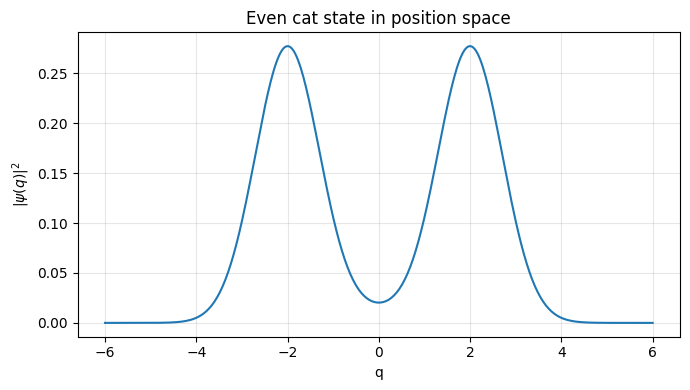

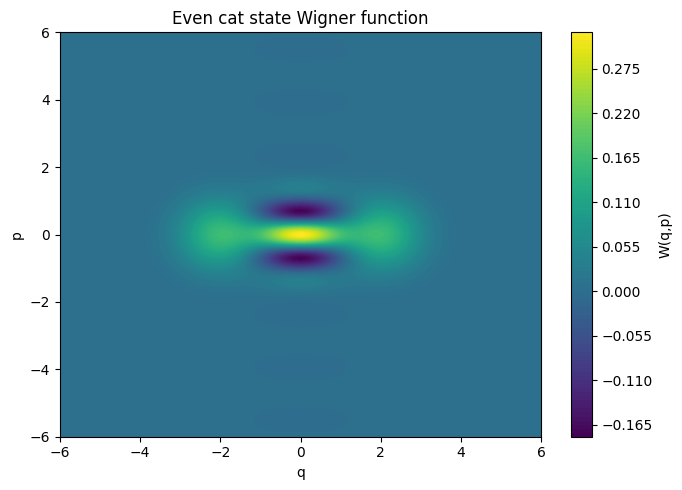

/var/folders/sf/j_bpvxs106x0w5f73qjrvpfh0000gn/T/ipykernel_8671/858049587.py:138: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


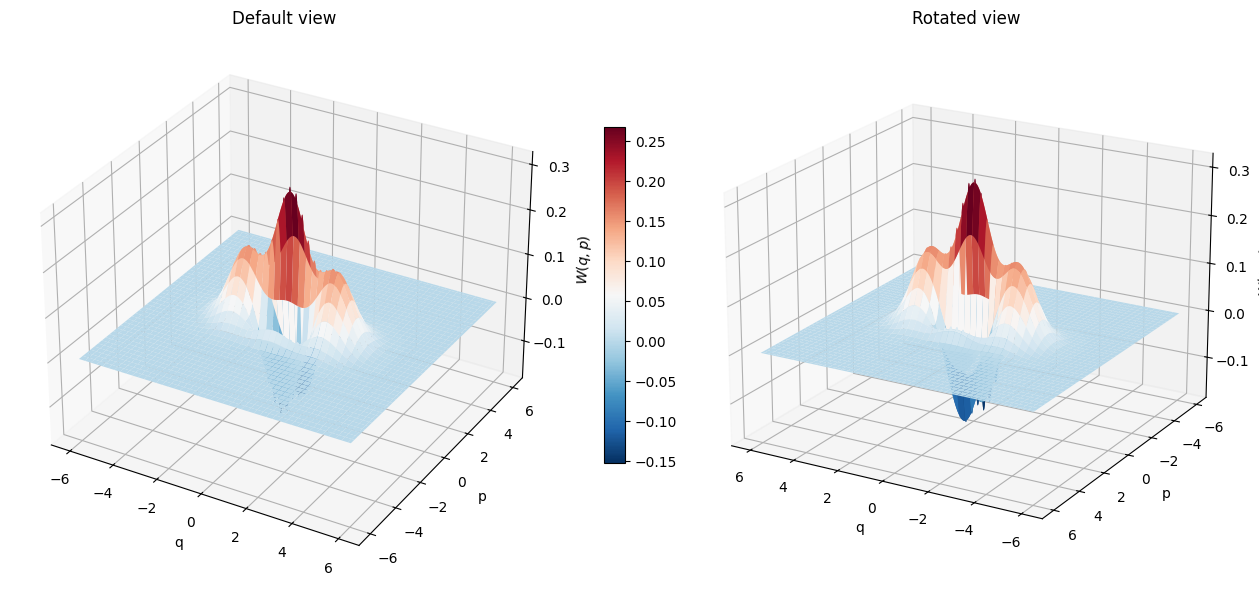

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Cat state wavefunction in position space
# |cat> = N (|+a> + s |-a>)
# where s = +1 for even cat, s = -1 for odd cat
# ------------------------------------------------------------
def cat_wavefunction(q, a, parity="even"):
    s = +1 if parity.lower() == "even" else -1

    # Single coherent-state-like Gaussian packet in q
    # vacuum width convention: psi0(q) = pi^(-1/4) exp(-q^2/2)
    g_plus = np.pi ** (-0.25) * np.exp(-0.5 * (q - a) ** 2)
    g_minus = np.pi ** (-0.25) * np.exp(-0.5 * (q + a) ** 2)

    # Overlap <+a|-a> = exp(-a^2) in this convention
    N = 1.0 / np.sqrt(2.0 * (1.0 + s * np.exp(-a**2)))

    return N * (g_plus + s * g_minus)


# ------------------------------------------------------------
# Analytic Wigner function for the cat state
#
# W(q,p) = N^2 / pi * [
#   exp(-(q-a)^2 - p^2)
# + exp(-(q+a)^2 - p^2)
# + 2 s exp(-q^2 - p^2) cos(2 a p)
# ]
#
# with s = +1 (even cat), s = -1 (odd cat)
# ------------------------------------------------------------
def cat_wigner(q, p, a, parity="even"):
    s = +1 if parity.lower() == "even" else -1

    # Normalization from overlap <+a|-a> = exp(-a^2)
    N = 1.0 / np.sqrt(2.0 * (1.0 + s * np.exp(-a**2)))

    Q, P = np.meshgrid(q, p, indexing="xy")

    W = (N**2 / np.pi) * (
        np.exp(-(Q - a) ** 2 - P**2)
        + np.exp(-(Q + a) ** 2 - P**2)
        + 2.0 * s * np.exp(-Q**2 - P**2) * np.cos(2.0 * a * P)
    )

    return W


# ------------------------------------------------------------
# Example: plot an even cat state
# ------------------------------------------------------------
a = 2.0
parity = "even"

q = np.linspace(-6, 6, 401)
p = np.linspace(-6, 6, 401)

psi_q = cat_wavefunction(q, a, parity=parity)
W = cat_wigner(q, p, a, parity=parity)

# Position-space density
plt.figure(figsize=(7, 4))
plt.plot(q, np.abs(psi_q) ** 2)
plt.xlabel("q")
plt.ylabel(r"$|\psi(q)|^2$")
plt.title(f"{parity.capitalize()} cat state in position space")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wigner heatmap
plt.figure(figsize=(7, 5))
plt.contourf(q, p, W, levels=100)
plt.xlabel("q")
plt.ylabel("p")
plt.title(f"{parity.capitalize()} cat state Wigner function")
plt.colorbar(label="W(q,p)")
plt.tight_layout()
plt.show()

# Wigner 3D surface
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

Q, P = np.meshgrid(q, p, indexing="xy")

fig = plt.figure(figsize=(14,6))

# ---------------------------------------------------
# Left: Default view
# ---------------------------------------------------
ax1 = fig.add_subplot(121, projection='3d')

surf1 = ax1.plot_surface(
    Q, P, W,
    cmap='RdBu_r',
    linewidth=0,
    antialiased=True
)

ax1.set_xlabel("q")
ax1.set_ylabel("p")
ax1.set_zlabel(r"$W(q,p)$")
ax1.set_title("Default view")

# Default Matplotlib viewing angle
ax1.view_init(elev=30, azim=-60)

# ---------------------------------------------------
# Right: Rotated view
# ---------------------------------------------------
ax2 = fig.add_subplot(122, projection='3d')

surf2 = ax2.plot_surface(
    Q, P, W,
    cmap='RdBu_r',
    linewidth=0,
    antialiased=True
)

ax2.set_xlabel("q")
ax2.set_ylabel("p")
ax2.set_zlabel(r"$W(q,p)$")
ax2.set_title("Rotated view")

# Choose your favourite angle here
ax2.view_init(elev=20, azim=120)

# Leave some space between the plots
fig.subplots_adjust(wspace=0.25)

# [left, bottom, width, height]
cax = fig.add_axes([0.485, 0.22, 0.015, 0.56])

fig.colorbar(surf1, cax=cax)

plt.tight_layout()
plt.show()